# Deep Learning Baseline; PyTorch MLP
## Week 3, Day 1: Deep Learning Foundations & Tensor Architecture

**Objective:** Transition from Scikit-Learn to PyTorch. Convert the cleaned loan default dataset into PyTorch tensors, build a custom Multi-Layer Perceptron (MLP), and train it using a manual training loop with explicit forward pass, loss calculation, backpropagation, and optimizer steps no `.fit()` abstractions allowed.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

PyTorch version: 2.12.1+cpu
CUDA available: False


## 1. Load Dataset and Prepare Tensors
Loading the cleaned loan default dataset, separating features (X) and target (y), and converting them into PyTorch tensors. Features use FloatTensor, target uses LongTensor (required for classification with CrossEntropyLoss).

In [2]:
df = pd.read_csv('loan_default_dataset.csv')
print("Shape:", df.shape)
 
df['Annual_Income'] = df['Annual_Income'].fillna(df['Annual_Income'].median())
df['Employment_Years'] = df['Employment_Years'].fillna(df['Employment_Years'].median())

df['Credit_Score'] = df['Credit_Score'].clip(300, 850)
df['Loan_Amount'] = df['Loan_Amount'].clip(upper=df['Loan_Amount'].quantile(0.99))

categorical_cols = ['Home_Ownership', 'Loan_Purpose', 'Marital_Status', 'Education']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True, dtype=int)

X = df_encoded.drop(columns=['Default']).values
y = df_encoded['Default'].values

print("X shape:", X.shape)
print("y shape:", y.shape)

Shape: (5000, 15)
X shape: (5000, 22)
y shape: (5000,)


## 2. Train-Test Split and Tensor Conversion
Splitting data 80/20, scaling features (fit on train only), then converting to PyTorch tensors.

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_tensor = torch.FloatTensor(X_train_scaled)
y_train_tensor = torch.LongTensor(y_train)
X_test_tensor = torch.FloatTensor(X_test_scaled)
y_test_tensor = torch.LongTensor(y_test)

print("X_train_tensor shape:", X_train_tensor.shape, "dtype:", X_train_tensor.dtype)
print("y_train_tensor shape:", y_train_tensor.shape, "dtype:", y_train_tensor.dtype)
print("X_test_tensor shape:", X_test_tensor.shape, "dtype:", X_test_tensor.dtype)
print("y_test_tensor shape:", y_test_tensor.shape, "dtype:", y_test_tensor.dtype)

X_train_tensor shape: torch.Size([4000, 22]) dtype: torch.float32
y_train_tensor shape: torch.Size([4000]) dtype: torch.int64
X_test_tensor shape: torch.Size([1000, 22]) dtype: torch.float32
y_test_tensor shape: torch.Size([1000]) dtype: torch.int64


## 3. Build Custom MLP Architecture
Subclassing torch.nn.Module to build a Multi-Layer Perceptron with an input layer, one hidden layer with ReLU activation, and an output layer for binary classification.

**Why ReLU instead of Sigmoid?**
Sigmoid's derivative is at most 0.25 and approaches zero for large positive or negative inputs  this causes the vanishing gradient problem, where gradients shrink exponentially as they propagate backward through multiple layers, making early layers learn extremely slowly or not at all. ReLU's derivative is exactly 1 for any positive input and 0 for negative input gradients either pass through unchanged or stop, but they never shrink toward zero across layers the way Sigmoid's do. This makes deep networks trainable.

In [4]:
class LoanDefaultMLP(nn.Module):
    def __init__(self, input_size, hidden_size=16, output_size=2):
        super(LoanDefaultMLP, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

model = LoanDefaultMLP(input_size=X_train_tensor.shape[1])
print(model)

LoanDefaultMLP(
  (fc1): Linear(in_features=22, out_features=16, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=16, out_features=2, bias=True)
)


## 4. Manual Training Loop
Implementing the training loop explicitly across 20 epochs: zero gradients, forward pass, compute loss, backpropagate, and update weights via the optimizer. No `.fit()` abstraction is used,every step is written manually.

In [5]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

epochs = 20
loss_history = []

for epoch in range(epochs):
    
    optimizer.zero_grad()

    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)

    loss.backward()

    optimizer.step()

    loss_history.append(loss.item())
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

Epoch [1/20], Loss: 0.8028
Epoch [2/20], Loss: 0.7429
Epoch [3/20], Loss: 0.6898
Epoch [4/20], Loss: 0.6432
Epoch [5/20], Loss: 0.6027
Epoch [6/20], Loss: 0.5681
Epoch [7/20], Loss: 0.5388
Epoch [8/20], Loss: 0.5144
Epoch [9/20], Loss: 0.4944
Epoch [10/20], Loss: 0.4782
Epoch [11/20], Loss: 0.4655
Epoch [12/20], Loss: 0.4557
Epoch [13/20], Loss: 0.4482
Epoch [14/20], Loss: 0.4426
Epoch [15/20], Loss: 0.4386
Epoch [16/20], Loss: 0.4356
Epoch [17/20], Loss: 0.4334
Epoch [18/20], Loss: 0.4318
Epoch [19/20], Loss: 0.4304
Epoch [20/20], Loss: 0.4291


## 5. Training Loss Visualization
Plotting the loss curve across all 20 epochs to visually confirm convergence.

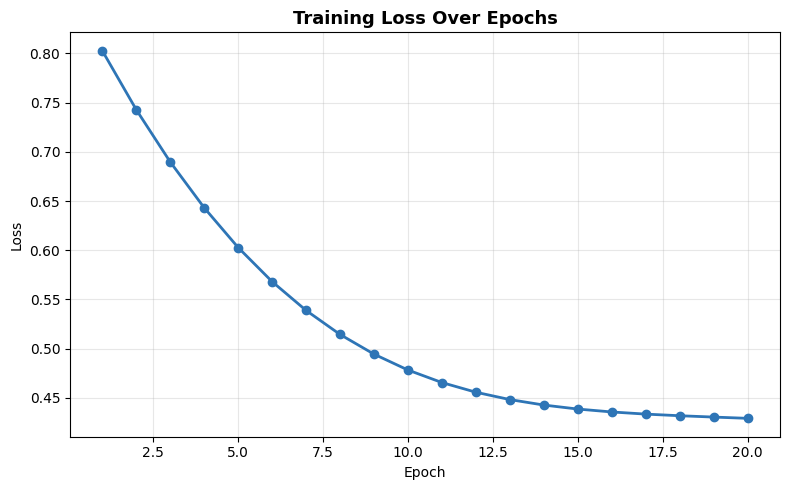

Saved training_loss.png


In [6]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs+1), loss_history, marker='o', color='#2E75B6', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Over Epochs', fontweight='bold', fontsize=13)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('training_loss.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved training_loss.png")

## 6. Evaluate on Test Set

In [7]:
model.eval()
with torch.no_grad():
    test_outputs = model(X_test_tensor)
    _, predicted = torch.max(test_outputs, 1)
    accuracy = (predicted == y_test_tensor).float().mean()

print(f"Test Accuracy: {accuracy.item():.4f}")

from sklearn.metrics import classification_report
print("\nClassification Report:")
print(classification_report(y_test_tensor.numpy(), predicted.numpy()))

Test Accuracy: 0.8370

Classification Report:
              precision    recall  f1-score   support

           0       0.84      1.00      0.91       837
           1       0.00      0.00      0.00       163

    accuracy                           0.84      1000
   macro avg       0.42      0.50      0.46      1000
weighted avg       0.70      0.84      0.76      1000



D:\Prosensia Internship\ML Tasks\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\Prosensia Internship\ML Tasks\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\Prosensia Internship\ML Tasks\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result

## Conclusion: Deep Learning Baseline

### Results
- Final Training Loss after 20 epochs: 0.4291 (down from 0.8028) smooth, consistent convergence
- Test Accuracy: 0.8370
- Class 1 (Default) Precision/Recall: 0.00,  model collapsed into predicting only the majority class

### Why the high accuracy is misleading
This is the same Accuracy Fallacy pattern observed across Week 2 (Day 11, Day 12). With 83.7% of the test set belonging to class 0, a model that predicts class 0 for every single sample achieves exactly 83.7% accuracy while learning nothing about distinguishing defaulters. The classification report confirms this  Recall and Precision on class 1 are both 0.00.

### Why this happened
Unlike the Weekend Project pipeline, this MLP was trained directly on the original imbalanced data without SMOTE. CrossEntropyLoss by default weighs all samples equally, so with an 84/16 class split, the optimizer found that always predicting class 0 minimizes loss almost as effectively as learning real patterns  especially with only 20 epochs and a simple 1-hidden-layer architecture.

### NumPy Arrays vs PyTorch Tensors
NumPy arrays are static, CPU-only, multi-dimensional containers used for numerical computation  they have no built-in mechanism for tracking how values were computed. PyTorch Tensors look similar on the surface (multi-dimensional arrays of numbers) but carry two critical additional capabilities: **autograd**, which automatically tracks every mathematical operation performed on a tensor to compute gradients during backpropagation, and **device flexibility**, allowing the exact same tensor and operations to run on CPU or GPU by simply moving the tensor with `.to(device)`. NumPy cannot do either of these natively. This is precisely why deep learning requires tensors  the manual training loop above only works because `loss.backward()` can traverse the entire computational graph PyTorch built automatically as we performed the forward pass.

### Why ReLU Solves Vanishing Gradients
Sigmoid squashes any input into a range between 0 and 1, and its derivative peaks at only 0.25 (at x=0) and rapidly approaches 0 as inputs move away from zero in either direction. When multiplying many such small derivatives together across layers during backpropagation, the gradient signal shrinks exponentially by the time it reaches early layers, it's effectively zero, and those layers stop learning. ReLU's derivative is binary: exactly 1 for any positive input, 0 for negative input. There is no shrinking multiplication chain  a gradient either passes through completely unchanged or is blocked entirely. This is mathematically why deep networks with many layers became trainable once ReLU replaced Sigmoid as the standard hidden-layer activation.

### Key Takeaways
- A manually written PyTorch training loop gives full visibility into every step (zero_grad, forward, loss, backward, step) that `.fit()` abstracts away in Scikit-Learn
- The Accuracy Fallacy applies to deep learning exactly as it does to classical ML class imbalance must be addressed regardless of which framework is used
- Future iterations of this MLP should apply SMOTE (as done in the Weekend Project) or use a weighted loss function (`nn.CrossEntropyLoss(weight=...)`) to prevent majority-class collapse
- ReLU's piecewise-linear gradient behavior is what makes modern deep networks trainable at depth, unlike Sigmoid which saturates and kills gradient flow